In [37]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [38]:
X = []
labels = []
with open("textck.txt", "r") as file:
     for line in file:
         line = line.split()
         X.append(line[0:2])
         labels.append(line[2])
         
X = np.asarray(X, dtype=np.float64)
labels = np.asarray(labels, dtype=np.int8)
print(X)
print(labels)

[[1.359 2.163]
 [1.253 2.883]
 [1.418 2.772]
 [1.528 3.31 ]
 [3.793 0.576]
 [4.086 0.227]
 [3.711 0.802]
 [3.579 1.272]
 [2.693 1.998]
 [1.61  1.095]
 [2.351 3.21 ]
 [2.112 1.834]
 [4.476 0.092]
 [2.844 0.755]
 [2.563 0.492]
 [4.329 1.224]
 [0.881 3.367]
 [0.87  1.631]
 [0.918 3.148]
 [5.332 0.326]
 [3.3   0.857]
 [3.191 0.808]]
[1 1 1 1 0 0 0 0 1 1 1 1 0 0 0 0 1 1 1 0 0 0]


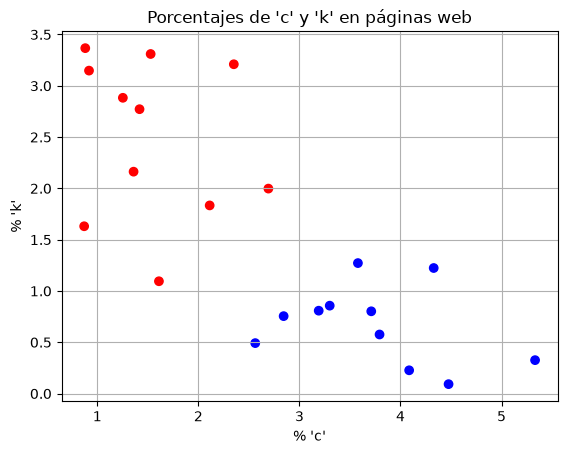

In [39]:
fig, ax = plt.subplots()

ax.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap="bwr"
)
ax.grid()
ax.set_xlabel("% 'c'")
ax.set_ylabel("% 'k'")
ax.set_title("Porcentajes de 'c' y 'k' en páginas web")
plt.show()

In [40]:
class Perceptron:
    def __init__(self, learning_rate, boundary):
        self.learning_rate = learning_rate
        self.boundary = boundary
        self.weights_history = []

    def activation_function(self, potential):
        return 1 if potential >= 0 else 0

    def fit(self, X, labels, w, epochs):
        """
        Learning algorithm
        """

        # First start with a initialized weights vector
        self.weights_history = [w.copy()]
        print(f"W[0] = {w} ")
        start = time.perf_counter()
        for epoch in range(epochs):
            print("Época ", epoch)
            errors_in_epoch = 0
            
            for i in range(len(X)):
                potential = np.dot(X[i], w) - self.boundary
            
                y = self.activation_function(potential)
    
                error = labels[i] - y

                if error != 0:
                    w = w + self.learning_rate * error * X[i]
                    self.weights_history.append(w.copy())
                    errors_in_epoch += 1
                    print(f"W[{i}] = {w} ")

            if errors_in_epoch == 0:
                print(f"El sistema convergió en la época {epoch}")
                break
            
        elapsed = time.perf_counter() - start
        print(f'Simple perceptron algorithm lasts {elapsed}s')

    def get_weights_history(self):
        return self.weights_history